# 03. Building Agents: From Simple Prompting to Tool-Using Agents

In Notebook 02 we saw that different LLMs vary widely in accuracy on
quant-finance interview questions. Can we improve a cheap model's
performance through better **prompting** and **tool use** -- without
switching to a more expensive model?

This notebook examines results from four progressively more sophisticated
approaches, all using **`openai/gpt-4o-mini`** via OpenRouter:

| # | Approach | What changes | Key idea |
|---|----------|-------------|----------|
| 1 | **Baseline** | Minimal prompt, no reasoning | Just ask the question |
| 2 | **Chain-of-Thought** | Expert prompt with step-by-step reasoning | Decompose hard problems |
| 3 | **Tool Use** | Same prompt + calculator tool | Offload arithmetic |
| 4 | **LangGraph Agent** | Same prompt + tool, automated loop | Framework for agents |

The experiments were run by `agent_runner.py` (via `doit
run_agent_experiments`). This notebook loads the pre-computed results
and walks through what each approach does and why it helps.

**Why `gpt-4o-mini`?** It is one of the cheapest models that supports
OpenAI-style function calling -- a requirement for Sections 3 and 4.
Smaller open-source models (e.g. Llama 3.1 8B) are cheaper, but they
don't reliably produce well-formed tool calls through OpenRouter.

## Background Reading

The techniques in this notebook are grounded in three influential papers:

**1. Chain-of-Thought Prompting Elicits Reasoning in Large Language Models**
(Wei et al., NeurIPS 2022)

> *Generating a chain of thought -- a series of intermediate reasoning
> steps -- significantly improves the ability of large language models to
> perform complex reasoning.*

The key finding: simply adding reasoning demonstrations (or even just the
phrase "let's think step by step") to a prompt can dramatically improve
performance on math and logic tasks. The model doesn't get new knowledge --
it just uses what it already knows more effectively.

**2. ReAct: Synergizing Reasoning and Acting in Language Models**
(Yao et al., ICLR 2023)

> *ReAct prompts LLMs to generate both verbal reasoning traces and
> task-specific actions in an interleaved manner.*

ReAct introduced the **Thought / Action / Observation** loop: the model
*thinks* about what to do, *acts* (e.g. calls a tool), *observes* the
result, and then *thinks* again. This interleaving of reasoning and acting
makes the model more grounded and less prone to hallucination than
chain-of-thought alone.

**3. Toolformer: Language Models Can Teach Themselves to Use Tools**
(Schick et al., 2023)

> *LMs can teach themselves to use external tools via simple APIs and
> achieve the best of both worlds.*

Toolformer showed that giving a language model access to external tools --
a calculator, a search engine, a calendar -- lets it overcome fundamental
limitations like poor arithmetic, without sacrificing its language abilities.

---
## 1. Load Results

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from settings import config

DATA_DIR = config("DATA_DIR")
OUTPUT_DIR = config("OUTPUT_DIR")

RESULTS_CSV = DATA_DIR / "agent_results" / "agent_results.csv"
df = pd.read_csv(RESULTS_CSV)
df["is_correct"] = df["is_correct"].astype(bool)

print(
    f"Loaded {len(df)} results: "
    f"{df['approach'].nunique()} approaches x "
    f"{df['question_id'].nunique()} questions"
)
df.head()

Loaded 252 results: 4 approaches x 63 questions


,approach,question_id,question_type,title,source_book,chapter,difficulty,reference_answer,extracted_answer,is_correct,grader_explanation,tool_calls_made,error
0,1_baseline,text_only_q001,text_only,Screwy pirates,green_book,Ch 2,NaN,Pirates 1 and 3 get 1 coin each; pirate 5 keep...,"98 coins to the most senior pirate, 1 coin to ...",True,The candidate's answer is mathematically equiv...,0,NaN
1,1_baseline,text_only_q002,text_only,Tiger and sheep,green_book,Ch 2,NaN,The sheep will not be eaten (100 is even),Yes,False,The candidate's answer does not provide the re...,0,NaN
2,1_baseline,text_only_q003,text_only,River crossing,green_book,Ch 2,NaN,17 minutes,17 minutes,True,The candidate's answer matches the reference a...,0,NaN
3,1_baseline,text_only_q004,text_only,Birthday problem,green_book,Ch 2,NaN,September 1,June 7,False,The candidate's answer is incorrect because th...,0,NaN
4,1_baseline,text_only_q005,text_only,Card game,green_book,Ch 2,NaN,Do not play; the expected payoff is negative f...,$50,False,The candidate's answer does not address the qu...,0,NaN


---
## 2. Baseline -- Naive Prompting

The baseline uses the simplest possible approach: a **minimal system
prompt** that asks for a one-line answer with **no explanation**, and a
small token budget (256 tokens).

```python
SYSTEM_PROMPT_BASELINE = (
    "Give a one-line answer to the following question. "
    "No explanation needed.\n\n"
    "End with FINAL ANSWER: <your answer>"
)

response = client.chat.completions.create(
    model="openai/gpt-4o-mini",
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT_BASELINE},
        {"role": "user", "content": question_text},
    ],
    max_tokens=256,
)
```

Without room to reason, the model must guess. This represents what you
get if you fire a question at a cheap model and hope for the best.

In [2]:
baseline = df[df["approach"] == "1_baseline"]
print(f"Baseline accuracy: {baseline['is_correct'].sum()}/{len(baseline)} = {baseline['is_correct'].mean():.0%}")
baseline[["question_id", "title", "is_correct", "extracted_answer"]].head(10)

Baseline accuracy: 31/63 = 49%


,question_id,title,is_correct,extracted_answer
0,text_only_q001,Screwy pirates,True,"98 coins to the most senior pirate, 1 coin to ..."
1,text_only_q002,Tiger and sheep,False,Yes
2,text_only_q003,River crossing,True,17 minutes
3,text_only_q004,Birthday problem,False,June 7
4,text_only_q005,Card game,False,$50
5,text_only_q006,Burning ropes,True,Light one end of the first rope and both ends ...
6,text_only_q007,Trailing zeros,True,24
7,text_only_q008,Horse race,True,7
8,text_only_q009,Infinite sequence,False,2
9,text_only_q010,Calendar cubes,True,"0, 1, 2, 3, 4, 5 on one die and 0, 1, 2, 6, 7,..."


---
## 3. Chain-of-Thought Prompting

**Key idea from Wei et al. (2022):** By asking the model to "think step by
step," we give it space to decompose hard problems into manageable pieces.

### What Changes

Two things change relative to the baseline:

1. **System prompt** -- we frame the model as an expert and explicitly ask
   it to reason step by step.
2. **Token budget** -- we increase `max_tokens` from 256 to 4096 so the
   model has room to reason before answering. This is critical: without
   space to "think on paper," the model can't decompose multi-step
   problems.

```python
SYSTEM_PROMPT_COT = (
    "You are an expert in quantitative finance, probability, "
    "statistics, and mathematical reasoning. ...\n\n"
    "Read the question carefully and solve it step by step. "
    "Show your reasoning clearly. ...\n\n"
    "FINAL ANSWER: <your concise final answer here>"
)

response = client.chat.completions.create(
    model="openai/gpt-4o-mini",
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT_COT},
        {"role": "user", "content": question_text},
    ],
    max_tokens=4096,
)
```

In [3]:
cot = df[df["approach"] == "2_chain_of_thought"]
print(f"CoT accuracy: {cot['is_correct'].sum()}/{len(cot)} = {cot['is_correct'].mean():.0%}")

# Which questions flipped?
merged_bc = baseline[["question_id", "title", "is_correct"]].merge(
    cot[["question_id", "is_correct"]],
    on="question_id",
    suffixes=("_baseline", "_cot"),
)
merged_bc["change"] = merged_bc.apply(
    lambda r: (
        "IMPROVED"
        if not r["is_correct_baseline"] and r["is_correct_cot"]
        else (
            "REGRESSED"
            if r["is_correct_baseline"] and not r["is_correct_cot"]
            else "no change"
        )
    ),
    axis=1,
)
display(Markdown("**Questions that changed with CoT:**"))
merged_bc[merged_bc["change"] != "no change"][
    ["question_id", "title", "is_correct_baseline", "is_correct_cot", "change"]
].reset_index(drop=True)

CoT accuracy: 44/63 = 70%


**Questions that changed with CoT:**

,question_id,title,is_correct_baseline,is_correct_cot,change
0,text_only_q002,Tiger and sheep,False,True,IMPROVED
1,text_only_q009,Infinite sequence,False,True,IMPROVED
2,text_only_q015,Quant salary,False,True,IMPROVED
3,text_only_q016,Coin piles,False,True,IMPROVED
4,text_only_q018,Wise men,False,True,IMPROVED
5,text_only_q020,Missing integers,False,True,IMPROVED
6,text_only_q021,Counterfeit coins I,False,True,IMPROVED
7,text_only_q029,Coin split problem,False,True,IMPROVED
8,text_only_q032,Rainbow hats,False,True,IMPROVED
9,text_only_q033,Coin toss game,True,False,REGRESSED


---
## 4. Tool Use via OpenAI Function Calling

Chain-of-thought helps the model *reason*, but even smart models make
arithmetic mistakes. The insight from **Toolformer** (Schick et al., 2023)
is that we can give the model access to external tools -- like a
calculator -- so it can **offload computation**.

The **ReAct** pattern (Yao et al., 2022) tells us *how* to combine
reasoning and tool use: the model **thinks**, **acts** (calls a tool),
**observes** the result, and **thinks** again.

### The Calculator Tool

```python
def calculator(expression: str) -> str:
    """Evaluate a math expression in a sandboxed namespace."""
    SAFE = {"factorial": factorial, "comb": comb, "log": math.log, ...}
    return str(eval(expression, SAFE))
```

### The ReAct Loop (OpenAI function calling)

```python
TOOLS = [{"type": "function", "function": {
    "name": "calculator",
    "description": "Evaluate a mathematical expression...",
    "parameters": {"type": "object", "properties": {
        "expression": {"type": "string"}
    }},
}}]

messages = [system_msg, user_msg]
for _ in range(max_iterations):
    response = client.chat.completions.create(
        model=MODEL, messages=messages,
        tools=TOOLS,   # <-- tools are available
    )
    msg = response.choices[0].message
    if not msg.tool_calls:      # model gave a final answer
        break
    # Execute each tool call and feed results back
    messages.append(msg)
    for tc in msg.tool_calls:
        result = calculator(json.loads(tc.function.arguments)["expression"])
        messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})
```

### Important Design Choice

We use the **same CoT system prompt** -- we do NOT add "use the calculator
tool." In testing, adding explicit tool-use instructions *hurt* performance
by making the model focus on calling the tool rather than reasoning about
the problem. The best approach: keep the CoT prompt and just make tools
*available*.

In [4]:
tools = df[df["approach"] == "3_tool_use"]
print(f"Tool use accuracy: {tools['is_correct'].sum()}/{len(tools)} = {tools['is_correct'].mean():.0%}")
print(f"Questions where tools were called: {(tools['tool_calls_made'] > 0).sum()}/{len(tools)}")
print(f"Total tool calls: {tools['tool_calls_made'].sum()}")

Tool use accuracy: 43/63 = 68%
Questions where tools were called: 3/63
Total tool calls: 15


---
## 5. Full Agent with LangGraph

The manual ReAct loop from Section 4 can be expressed as a **state graph**
using LangGraph:

```
START --> [agent] --tool calls?--> [tools] --> [agent] --> ... --> END
```

```python
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition

llm = ChatOpenAI(model=MODEL, base_url=OPENROUTER_URL, ...)
llm_with_tools = llm.bind_tools([calculator_tool])

def agent_node(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph = StateGraph(MessagesState)
graph.add_node("agent", agent_node)
graph.add_node("tools", ToolNode([calculator_tool]))
graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools", "agent")
agent = graph.compile()
```

The accuracy should be similar to Section 4 -- the value of LangGraph is
in code organization, composability, and debugging, not in producing
different results.

In [5]:
lg = df[df["approach"] == "4_langgraph_agent"]
print(f"LangGraph accuracy: {lg['is_correct'].sum()}/{len(lg)} = {lg['is_correct'].mean():.0%}")

LangGraph accuracy: 44/63 = 70%


---
## 6. Comparison and Analysis

In [6]:
summary = (
    df.groupby("approach")
    .agg(
        total=("is_correct", "count"),
        correct=("is_correct", "sum"),
        accuracy=("is_correct", "mean"),
        tool_calls=("tool_calls_made", "sum"),
    )
    .sort_index()
    .reset_index()
)
summary.style.format({"accuracy": "{:.0%}", "tool_calls": "{:.0f}"})

,approach,total,correct,accuracy,tool_calls
0,1_baseline,63,31,49%,0
1,2_chain_of_thought,63,44,70%,0
2,3_tool_use,63,43,68%,15
3,4_langgraph_agent,63,44,70%,8


### Accuracy by Approach

/var/folders/l3/tj6vb0ld2ys1h939jz0qrfrh0000gn/T/ipykernel_38607/2238794391.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


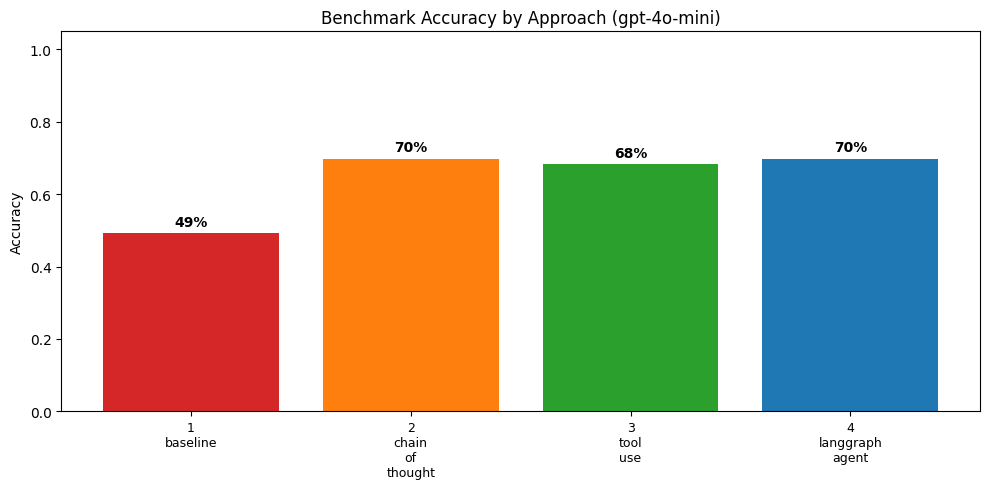

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
bars = ax.bar(summary["approach"], summary["accuracy"], color=colors)
ax.set_ylabel("Accuracy")
ax.set_title("Benchmark Accuracy by Approach (gpt-4o-mini)")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, summary["accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.0%}",
        ha="center",
        fontweight="bold",
    )
ax.set_xticklabels(
    [s.replace("_", "\n") for s in summary["approach"]],
    fontsize=9,
)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "agent_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Per-Question Heatmap

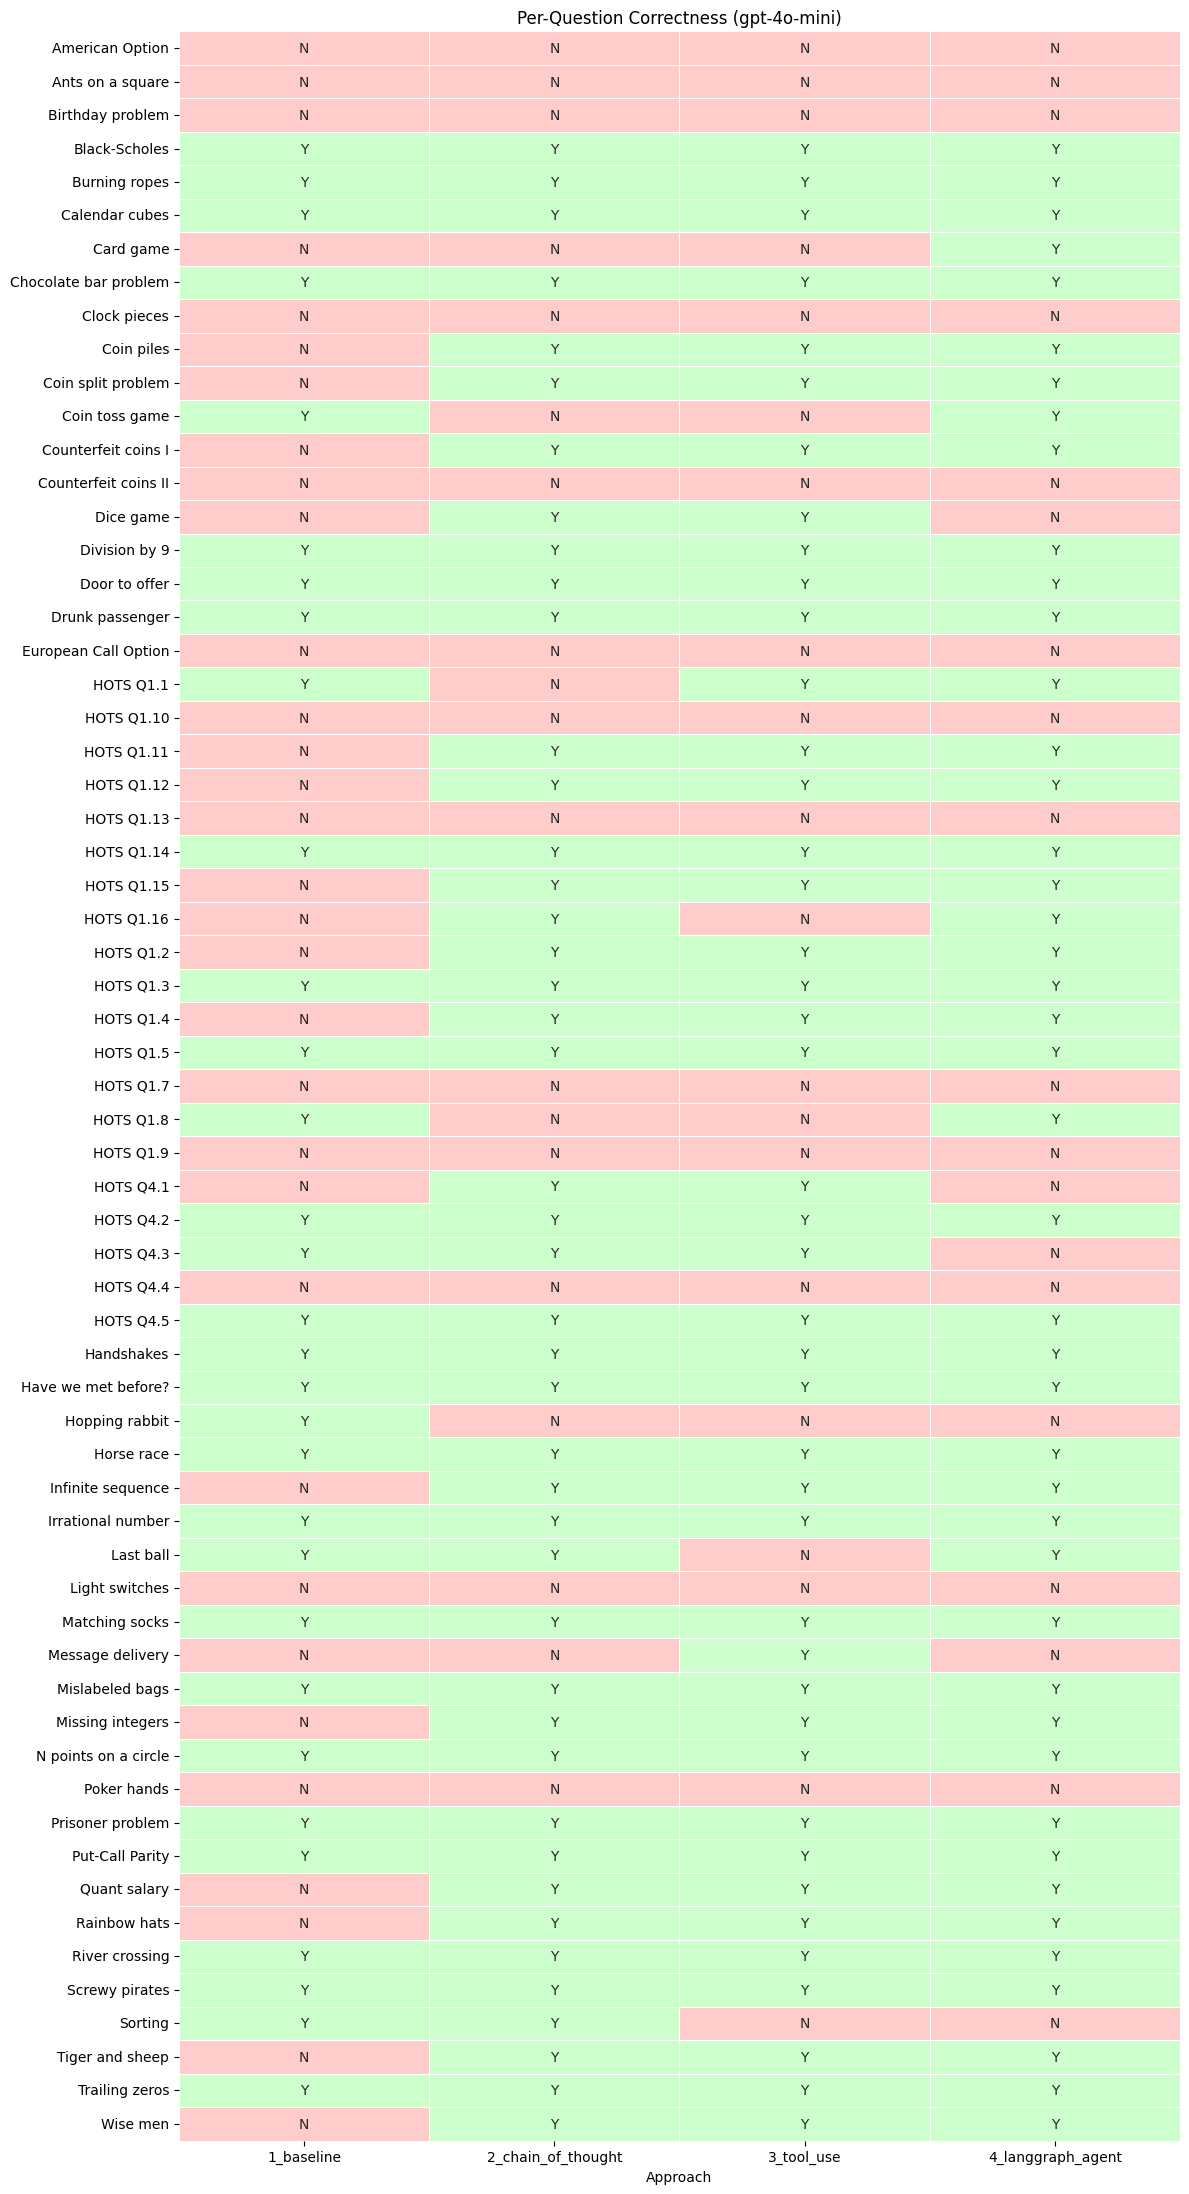

In [8]:
pivot = df.pivot_table(
    index="title",
    columns="approach",
    values="is_correct",
    aggfunc="first",
).reindex(
    columns=["1_baseline", "2_chain_of_thought", "3_tool_use", "4_langgraph_agent"]
)

fig, ax = plt.subplots(figsize=(12, max(8, len(pivot) * 0.35)))
sns.heatmap(
    pivot.astype(float),
    annot=pivot.replace({True: "Y", False: "N"}).values,
    fmt="",
    cmap=["#ffcccc", "#ccffcc"],
    cbar=False,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Per-Question Correctness (gpt-4o-mini)")
ax.set_xlabel("Approach")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "agent_per_question_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Questions That Improved

In [9]:
merged = baseline[["question_id", "title", "is_correct"]].rename(
    columns={"is_correct": "baseline"}
)
for name, approach in [("cot", "2_chain_of_thought"), ("tool_use", "3_tool_use"), ("langgraph", "4_langgraph_agent")]:
    merged = merged.merge(
        df[df["approach"] == approach][["question_id", "is_correct"]].rename(
            columns={"is_correct": name}
        ),
        on="question_id",
    )

improved = merged[
    ~merged["baseline"]
    & (merged["cot"] | merged["tool_use"] | merged["langgraph"])
]
display(Markdown(f"**{len(improved)} questions rescued by better prompting or tools:**"))
improved.reset_index(drop=True)

**19 questions rescued by better prompting or tools:**

,question_id,title,baseline,cot,tool_use,langgraph
0,text_only_q002,Tiger and sheep,False,True,True,True
1,text_only_q005,Card game,False,False,False,True
2,text_only_q009,Infinite sequence,False,True,True,True
3,text_only_q012,Message delivery,False,False,True,False
4,text_only_q015,Quant salary,False,True,True,True
5,text_only_q016,Coin piles,False,True,True,True
6,text_only_q018,Wise men,False,True,True,True
7,text_only_q020,Missing integers,False,True,True,True
8,text_only_q021,Counterfeit coins I,False,True,True,True
9,text_only_q029,Coin split problem,False,True,True,True


---
## 7. Key Takeaways

1. **Chain-of-thought prompting is free and effective.** It costs nothing
   extra -- just a better system prompt and a larger token budget -- yet it
   unlocks reasoning the model already has. The biggest single improvement
   comes from asking the model to think step by step.

2. **Tool use adds a safety net for arithmetic.** When the model
   recognizes it needs to compute something, the calculator tool ensures
   the computation is correct. The model decides when to call it -- we
   don't force it.

3. **The ReAct pattern (Thought / Action / Observation) is the key
   abstraction.** Whether you implement the loop by hand (Section 4) or
   use a framework (Section 5), the pattern is the same: reason about
   what to do, act, observe the result, reason again.

4. **Frameworks like LangGraph make agents composable.** The manual loop
   from Section 4 and the LangGraph agent from Section 5 produce similar
   results, but LangGraph makes it easy to add more tools, swap models,
   or compose multiple agents.

5. **Prompt design matters more than you think.** In testing, we found
   that adding instructions like "use the calculator tool" *hurt*
   performance. The best tool-use prompt was the same CoT prompt with
   tools simply *available*.